<a href="https://colab.research.google.com/github/guptadevanshu845-star/DS_Project/blob/main/Predictive_maintence_for_machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Predictive Maintenance for Manufacturing**
## Goal: Predict when machinery is likely to fail to avoid unplanned downtime.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical


# Step-1

In [ ]:
df= pd.read_csv('Predictive_maintenance_for_machine.csv')
df.head(10)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,0,0,0,0


In [ ]:
df.tail()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0,0,0,0,0,0


# Step-2 EDA

In [ ]:
df.shape

(10000, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [ ]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [ ]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


In [ ]:

for col in ['TWF', 'HDF', 'PWF', 'OSF','RNF']:
  print(F" {col} :{df[col].sum()}")


 TWF :46
 HDF :115
 PWF :95
 OSF :98
 RNF :19


In [ ]:
df.isna().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


# Step-3

Encode machine type (L / M / H) as ordinal

In [ ]:
type_map = {'L': 0, 'M': 1, 'H': 2}
df['Type_enc'] = df['Type'].map(type_map)

In [ ]:
df['Temp_diff']       = df['Process temperature [K]'] - df['Air temperature [K]']
df['Power']           = df['Torque [Nm]'] * df['Rotational speed [rpm]'] * (2 * np.pi / 60)  # Watts
df['Wear_per_torque'] = df['Tool wear [min]'] / (df['Torque [Nm]'] + 1e-6)
df['Speed_torque']    = df['Rotational speed [rpm]'] * df['Torque [Nm]']

FEATURES = [
    'Type_enc',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Temp_diff',
    'Power',
    'Wear_per_torque',
    'Speed_torque',
]

TARGET_BINARY     = 'Machine failure'
FAILURE_TYPES     = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

X = df[FEATURES].values
y_binary = df[TARGET_BINARY].values

# Step-4: train and Test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Train failures: {y_train.sum()} | Test failures: {y_test.sum()}")


Train: 8000 | Test: 2000
Train failures: 271 | Test failures: 68


# Step-5:Random Forest

In [ ]:
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: cw[0], 1: cw[1]}

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight=class_weight_dict,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)
y_prob_rf  = rf.predict_proba(X_test_sc)[:, 1]
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Failure', 'Failure']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")


Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.85      0.84      0.84        68

    accuracy                           0.99      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9822


Feature importance

In [ ]:
feat_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("\nTop Feature Importances:")
print(feat_imp.to_string())


Top Feature Importances:
Rotational speed [rpm]     0.173124
Tool wear [min]            0.169615
Torque [Nm]                0.164416
Power                      0.141547
Speed_torque               0.122689
Temp_diff                  0.094235
Wear_per_torque            0.064917
Air temperature [K]        0.040397
Process temperature [K]    0.022111
Type_enc                   0.006948


Step-6: XGBOOST

In [ ]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,   # handles class imbalance
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(
    X_train_sc, y_train,
    eval_set=[(X_test_sc, y_test)],
    verbose=False
)
y_pred_xgb = xgb_model.predict(X_test_sc)
y_prob_xgb = xgb_model.predict_proba(X_test_sc)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['No Failure', 'Failure']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")


Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.79      0.82      0.81        68

    accuracy                           0.99      2000
   macro avg       0.89      0.91      0.90      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9836


Step-7: LSTM

In [ ]:
X_train_lstm = X_train_sc.reshape(-1, 1, len(FEATURES))
X_test_lstm  = X_test_sc.reshape(-1, 1, len(FEATURES))
y_train_cat  = to_categorical(y_train, num_classes=2)
y_test_cat   = to_categorical(y_test,  num_classes=2)

lstm_model = Sequential([
    LSTM(64, input_shape=(1, len(FEATURES)), return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(2, activation='softmax')
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



Class weights for imbalance

In [ ]:
class_weights_lstm = {0: cw[0], 1: cw[1]}

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=5, monitor='val_loss')
]

history = lstm_model.fit(
    X_train_lstm, y_train_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.15,
    class_weight=class_weights_lstm,
    callbacks=callbacks,
    verbose=1
)

y_prob_lstm = lstm_model.predict(X_test_lstm)[:, 1]
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=['No Failure', 'Failure']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lstm):.4f}")


Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.6226 - loss: 0.5844 - val_accuracy: 0.9600 - val_loss: 0.5767 - learning_rate: 0.0010
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7782 - loss: 0.4527 - val_accuracy: 0.9633 - val_loss: 0.4718 - learning_rate: 0.0010
Epoch 3/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8021 - loss: 0.4103 - val_accuracy: 0.9625 - val_loss: 0.3380 - learning_rate: 0.0010
Epoch 4/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8210 - loss: 0.3570 - val_accuracy: 0.9350 - val_loss: 0.2633 - learning_rate: 0.0010
Epoch 5/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8247 - loss: 0.3768 - val_accuracy: 0.9142 - val_loss: 0.2537 - learning_rate: 0.0010
Epoch 6/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8240 - loss: 0.3471 - val_accuracy: 0.8950 - val_loss: 0.2581 - learning_rate: 0.0010
Epoch 7/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8331 - loss: 0

# Step-8:MULTICLASS: FAILURE TYPE CLASSIFICATION

In [ ]:
df_fail = df[df['Machine failure'] == 1].copy()

In [ ]:
def get_failure_type(row):
    for ft in ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']:
        if row[ft] == 1:
            return ft
    return 'Unknown'

df_fail['failure_type'] = df_fail.apply(get_failure_type, axis=1)
le = LabelEncoder()
df_fail['failure_label'] = le.fit_transform(df_fail['failure_type'])

X_fail = scaler.transform(df_fail[FEATURES].values)
y_fail = df_fail['failure_label'].values

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_fail, y_fail, test_size=0.25, random_state=42, stratify=y_fail
)

xgb_multi = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
xgb_multi.fit(X_tr2, y_tr2)
y_pred_multi = xgb_multi.predict(X_te2)

print("\nFailure Type Labels:", le.classes_)
print("\nClassification Report:")
print(classification_report(y_te2, y_pred_multi, target_names=le.classes_))


Failure Type Labels: ['HDF' 'OSF' 'PWF' 'TWF' 'Unknown']

Classification Report:
              precision    recall  f1-score   support

         HDF       0.94      1.00      0.97        29
         OSF       0.95      0.90      0.92        20
         PWF       0.92      1.00      0.96        23
         TWF       0.90      0.82      0.86        11
     Unknown       0.00      0.00      0.00         2

    accuracy                           0.93        85
   macro avg       0.74      0.74      0.74        85
weighted avg       0.91      0.93      0.92        85



# VISUALIZATIONS

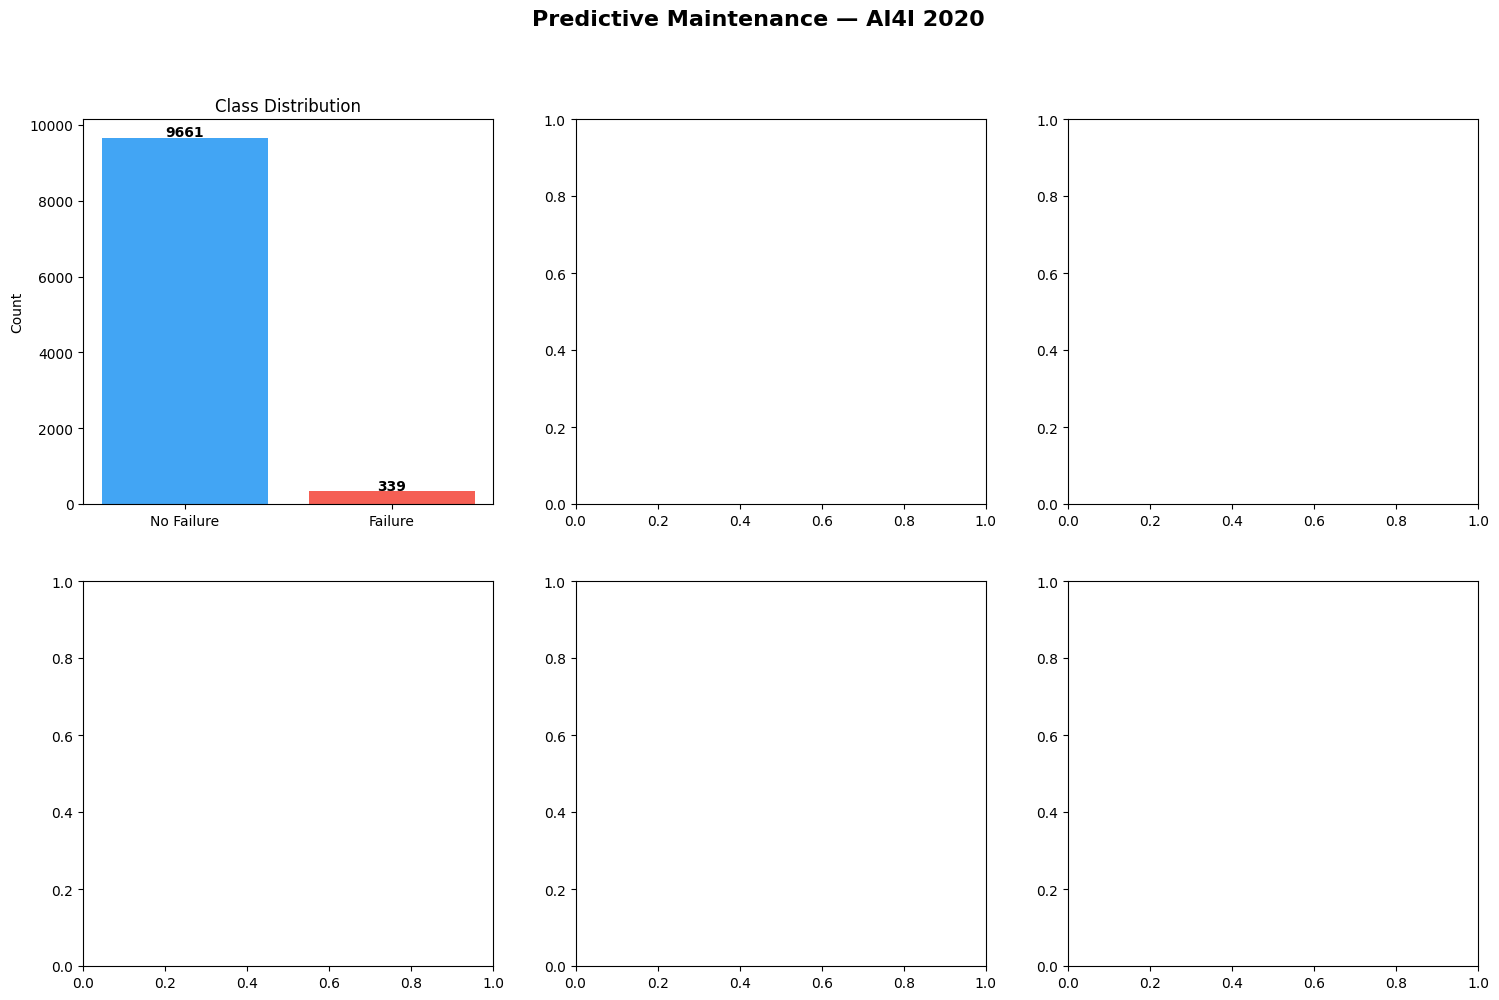

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Predictive Maintenance — AI4I 2020', fontsize=16, fontweight='bold')

# 9a. Class distribution
ax = axes[0, 0]
counts = df['Machine failure'].value_counts()
ax.bar(['No Failure', 'Failure'], counts.values, color=['#2196F3', '#F44336'], alpha=0.85)
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, str(v), ha='center', fontweight='bold')

In [ ]:
# 9b. Feature Importances (RF)
ax = axes[0, 1]
feat_imp.plot(kind='barh', ax=ax, color='#4CAF50', alpha=0.85)
ax.set_title('Random Forest Feature Importances')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.show()

In [ ]:
#9c. ROC Curves
ax = axes[0, 2]
for name, prob in [('Random Forest', y_prob_rf), ('XGBoost', y_prob_xgb), ('LSTM', y_prob_lstm)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(fontsize=9)

In [ ]:
# 9d. Confusion Matrix — XGBoost
ax = axes[1, 0]
cm = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm, display_labels=['No Failure', 'Failure']).plot(ax=ax, colorbar=False)
ax.set_title('XGBoost Confusion Matrix')

# 9e. LSTM Training History
ax = axes[1, 1]
ax.plot(history.history['loss'], label='Train Loss')
ax.plot(history.history['val_loss'], label='Val Loss')
ax.set_title('LSTM Training Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()

In [ ]:
# 9f. Failure Type Distribution
ax = axes[1, 2]
type_counts = {ft: df[ft].sum() for ft in FAILURE_TYPES}
ax.bar(type_counts.keys(), type_counts.values(), color='#FF9800', alpha=0.85)
ax.set_title('Failure Type Counts')
ax.set_ylabel('Count')
for i, (k, v) in enumerate(type_counts.items()):
    ax.text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('predictive_maintenance_results.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

# MODEL SUMMARY

In [ ]:
print("\n" + "=" * 60)
print("FINAL MODEL COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Model':<20} {'ROC-AUC':<12} {'Notes'}")
print("-" * 60)
print(f"{'Random Forest':<20} {roc_auc_score(y_test, y_prob_rf):<12.4f} class_weight='balanced'")
print(f"{'XGBoost':<20} {roc_auc_score(y_test, y_prob_xgb):<12.4f} scale_pos_weight={scale_pos:.1f}")
print(f"{'LSTM':<20} {roc_auc_score(y_test, y_prob_lstm):<12.4f} 2-layer + BatchNorm + Dropout")
print("=" * 60)
print("\nDataset:Predictive Maintenance (10,000 records)")
print("Features used:", FEATURES)



FINAL MODEL COMPARISON SUMMARY
Model                ROC-AUC      Notes
------------------------------------------------------------
Random Forest        0.9822       class_weight='balanced'
XGBoost              0.9836       scale_pos_weight=28.5
LSTM                 0.9701       2-layer + BatchNorm + Dropout

Dataset:Predictive Maintenance (10,000 records)
Features used: ['Type_enc', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temp_diff', 'Power', 'Wear_per_torque', 'Speed_torque']
